# CVSD Variability Metrics

## Project Overview

This notebook focuses on identifying **pulsating variable stars** using Rubin Observatory DP1 data. The goal is to compute and compare multiple **variability metrics** — particularly **Reduced Chi-Square (χ²)** and **Welch-Stetson I (I_WS)** — and evaluate their power to separate RR Lyrae, Cepheid, and Mira candidates based on time-series and color-magnitude characteristics.

---

## Goals

1. Detect pulsating stars from time-series photometry.
2. Calculate statistical measures that capture variability strength and behavior.
3. Compare results across different Rubin catalogs (`DiaSource`, `ForcedSource`, and `Object`).
4. Use CMDs and scatterplots to explore color-variability patterns.

In [160]:
# Libraries and Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

diasource = pd.read_csv("diasource.csv")
diaobject = pd.read_csv("diaobject.csv")
Object = pd.read_csv("object.csv")
diaobjectG = pd.read_csv("diaobjectG.csv")
diaobjectR = pd.read_csv("diaobjectR.csv")
diaobjectI = pd.read_csv("diaobjectI.csv")
objectG = pd.read_csv("objectG.csv")
objectR = pd.read_csv("objectR.csv")
objectI = pd.read_csv("objectI.csv")

In [161]:
# TAP Service 
from lsst.rsp import get_tap_service, retrieve_query
from pyvo.dal import TAPService
import lsst.daf.butler as dafButler
import lsst.geom
import lsst.afw.display as afwDisplay

service = get_tap_service("tap")
assert service is not None

In [121]:
# ForcedSource ADQL Query + Save to CSV
job_forced_source = service.run_async("""
SELECT TOP 1000000
    dp1.ForcedSource.coord_dec,
    dp1.ForcedSource.coord_ra,
    dp1.ForcedSource.objectId,
    dp1.ForcedSource.pixelFlags_bad,
    dp1.ForcedSource.pixelFlags_edge,
    dp1.ForcedSource.psfDiffFlux,
    dp1.ForcedSource.psfDiffFlux_flag,
    dp1.ForcedSource.psfDiffFluxErr,
    dp1.ForcedSource.psfFlux,
    dp1.ForcedSource.psfFlux_flag,
    dp1.ForcedSource.psfFluxErr,
    dp1.Visit.expMidptMJD AS mjd
FROM dp1.ForcedSource
JOIN dp1.Visit ON dp1.ForcedSource.visit = dp1.Visit.visit
""")
forcedsource_df = job_forced_source.to_table().to_pandas()
forcedsource_df.to_csv("forcedsource.csv", index=False)

2) Create a Reduced Chi Squared Formula to run through every observation and convert fluxes into apparent magnitudes

## Reduced Chi Squared Formula

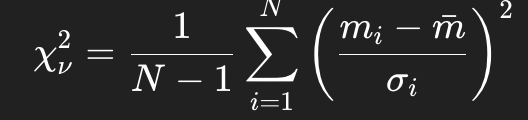

## Apparent Magnitude from Flux

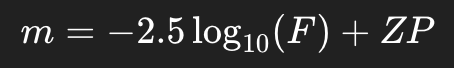

In [122]:
# DiaSource and DiaObject - how much stars vary based on real detections from changes night to night
# More focused, less extreme

ZP = 25 

# Quality filtering
diasource = diasource[
    (diasource["psfFlux"] > 0) &
    (~diasource["psfFlux_flag"]) &
    (~diasource["psfFlux_flag_edge"]) &
    (~diasource["psfFlux_flag_noGoodPixels"])
]

# Convert to magnitude
diasource["mag"] = -2.5 * np.log10(diasource["psfFlux"]) + ZP
diasource["mag_err"] = 1.0857 * diasource["psfFluxErr"] / diasource["psfFlux"]

# function to calculate Reduced Chi-Square 
def reduced_chi2(group):
    if len(group) <= 1:
        return np.nan # if only 1 observation or less, chi-square is undefined since it needs at least 2 points
    m = group["mag"].values
    m_err = group["mag_err"].values # extracts magnitudes and their errors for the current star
    weights = 1 / (m_err ** 2)
    weighted_mean = np.sum(weights * m) / np.sum(weights) # compute weighted mean magnitude, brighter (low-error) measurements will contribute more to the mean
    chi2 = np.sum(((m - weighted_mean) / m_err) ** 2) # summation of magnitude - magnitude mean over standard deviation and squared it
    return chi2 / (len(m) - 1) # divide by degrees of freedom to get chi-square

# Compute reduced chi² per diaObjectId (cleaner, avoids FutureWarning)
chi2_df = diasource.groupby("diaObjectId")[["mag", "mag_err"]].apply(reduced_chi2).reset_index()
chi2_df.columns = ["diaObjectId", "chi2_reduced"]

# merging with diaobject
g_band = pd.read_csv("diaobjectG.csv")
g_band["filter"] = "g"

r_band = pd.read_csv("diaobjectR.csv")
r_band["filter"] = "r"

i_band = pd.read_csv("diaobjectI.csv")
i_band["filter"] = "i"

# Combine DiaObject tables
diaobject_all = pd.concat([g_band, r_band, i_band], ignore_index=True)

# Merge chi² with DiaObject band labels
chi2_with_band = chi2_df.merge(diaobject_all[["diaObjectId", "filter"]], on="diaObjectId", how="left")

In [123]:
# ForcedSource and Object - how much stars vary in brightness when measured at same spot every night even if not clearly visible
# Catches subtle changes and faint stars, prone to noise and measurement errors

forcedsource = forcedsource[
    (forcedsource["psfFlux"] > 0) &
    (~forcedsource["psfFlux_flag"]) &
    (~forcedsource["pixelFlags_edge"])
]

forcedsource["mag"] = -2.5 * np.log10(forcedsource["psfFlux"]) + ZP
forcedsource["mag_err"] = 1.0857 * forcedsource["psfFluxErr"] / forcedsource["psfFlux"]

# Compute reduced chi² per ObjectId
chi2_df = forcedsource.groupby("objectId")[["mag", "mag_err"]].apply(reduced_chi2).reset_index()
chi2_df.columns = ["objectId", "chi2_reduced"]

# merging with object
object_g = pd.read_csv("objectG.csv")
object_g["filter"] = "g"
object_r = pd.read_csv("objectR.csv")
object_r["filter"] = "r"
object_i = pd.read_csv("objectI.csv")
object_i["filter"] = "i"

# Combine Object tables
object_all = pd.concat([object_g, object_r, object_i], ignore_index=True)

# Merge chi² with Object band labels
chi2_with_band = chi2_df.merge(object_all[["objectId", "filter"]], on="objectId", how="left")

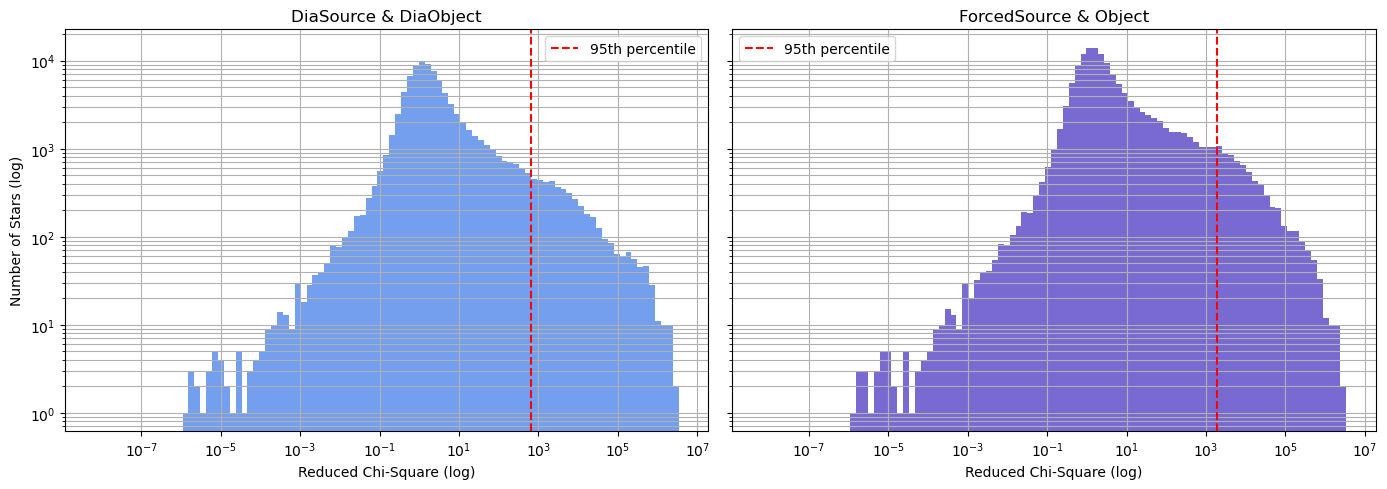

In [124]:
# Visualization (Drop zero and NA values)
diasource_chi2 = chi2_df["chi2_reduced"].dropna()
diasource_chi2 = diasource_chi2[diasource_chi2 > 0]

forced_chi2 = chi2_with_band["chi2_reduced"].dropna()
forced_chi2 = forced_chi2[forced_chi2 > 0]

# Log-spaced bins instead of linear since distributions are unreadable without log transformation
bins_dia = np.logspace(np.log10(diasource_chi2.min()), np.log10(diasource_chi2.max()), 100)
bins_forced = np.logspace(np.log10(forced_chi2.min()), np.log10(forced_chi2.max()), 100)

# 95th percentiles
p95_dia = np.percentile(diasource_chi2, 95)
p95_forced = np.percentile(forced_chi2, 95)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# DiaSource and DiaObject
axes[0].hist(diasource_chi2, bins=bins_dia, color='cornflowerblue', alpha=0.9)
axes[0].axvline(p95_dia, color='red', linestyle='--', label='95th percentile')
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Reduced Chi-Square (log)")
axes[0].set_ylabel("Number of Stars (log)")
axes[0].set_title("DiaSource & DiaObject")
axes[0].legend()
axes[0].grid(True, which='both')

# ForcedSource and Object
axes[1].hist(forced_chi2, bins=bins_forced, color='slateblue', alpha=0.9)
axes[1].axvline(p95_forced, color='red', linestyle='--', label='95th percentile')
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Reduced Chi-Square (log)")
axes[1].set_title("ForcedSource & Object")
axes[1].legend()
axes[1].grid(True, which='both')

plt.tight_layout()
plt.show()

3. Visualize reduced chi square, color, and create a CMD

In [166]:
chi2_df.to_csv("chi2_diasource.csv", index=False)
chi2_with_band.to_csv("chi2_forcedsource.csv", index=False)

In [167]:
chi2_df = pd.read_csv("chi2_diasource.csv")
chi2_df.rename(columns={"objectId": "diaObjectId"}, inplace=True)
chi2_df.to_csv("chi2_diasource.csv")

In [168]:
ZP = 25
# Filter good fluxes (avoid invalid logs)
Object = Object[
    (Object["g_psfFlux"] > 0) &
    (Object["r_psfFlux"] > 0) &
    (Object["i_psfFlux"] > 0)
]

# Convert psfFlux to magnitudes
Object["g_mag"] = -2.5 * np.log10(Object["g_psfFlux"]) + ZP
Object["r_mag"] = -2.5 * np.log10(Object["r_psfFlux"]) + ZP
Object["i_mag"] = -2.5 * np.log10(Object["i_psfFlux"]) + ZP

# Compute color indices
Object["g_r"] = Object["g_mag"] - Object["r_mag"]
Object["r_i"] = Object["r_mag"] - Object["i_mag"]
Object["g_i"] = Object["g_mag"] - Object["i_mag"]

# Keep key columns for classification
object_features = Object[[
    "objectId", "g_mag", "r_mag", "i_mag",
    "g_r", "r_i", "g_i",
    "g_extendedness", "r_extendedness", "i_extendedness"
]]

chi2_with_band = pd.read_csv("chi2_forcedsource.csv")  # forcedsource
features_with_band = object_features.merge(chi2_with_band, on="objectId") 
chi2_df = pd.read_csv("chi2_diasource.csv")  # diasource
features_df = diaobject.merge(chi2_df, on="diaObjectId") 

In [169]:
features_df.to_csv("chi2_diasource_features.csv", index=False)
features_with_band.to_csv("chi2_forcedsource_features.csv", index=False)

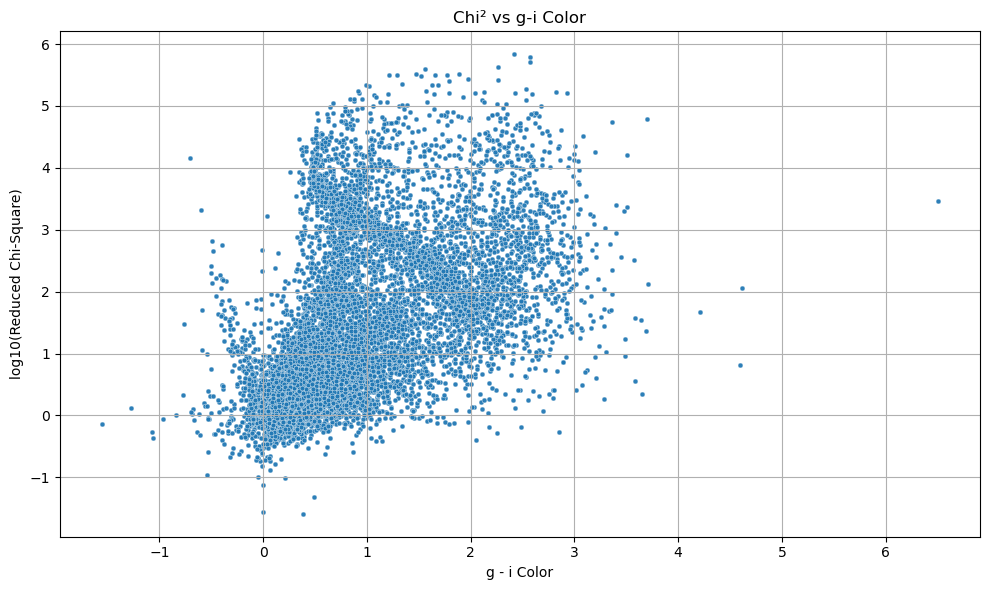

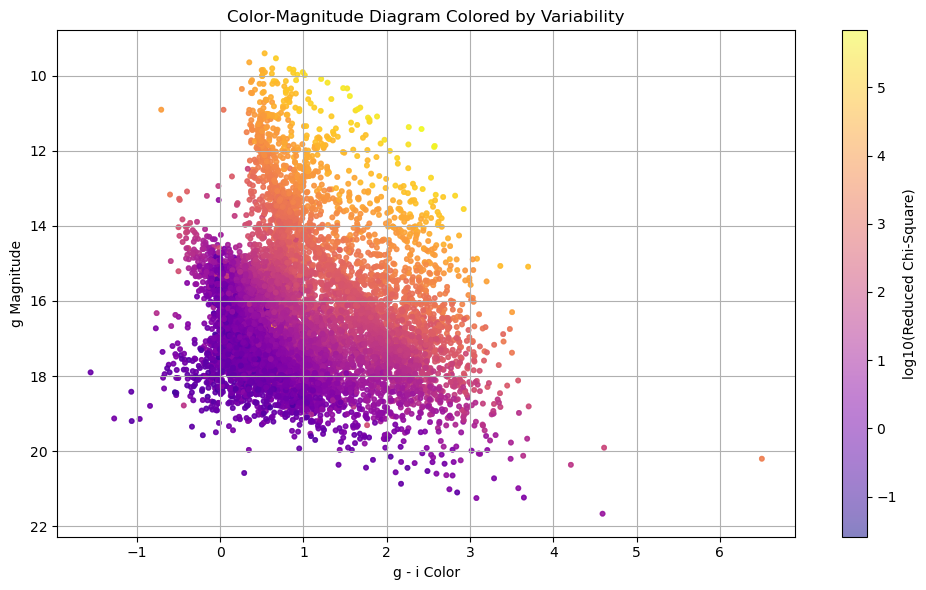

In [170]:
# Loading Object + ForcedSource Dataset
df = pd.read_csv("chi2_forcedsource_features.csv")

# Clean and filter
df = df[(df["chi2_reduced"] > 0) & (~df["g_i"].isna())].copy()
df["log_chi2"] = np.log10(df["chi2_reduced"])

# Chi^2 vs Color (g - i)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="g_i", y="log_chi2", s=12, alpha=0.6)
plt.xlabel("g - i Color")
plt.ylabel("log10(Reduced Chi-Square)")
plt.title("Chi² vs g-i Color")
plt.grid(True)
plt.tight_layout()
plt.show()

# Color Magnitude Diagram
plt.figure(figsize=(10, 6))
sc = plt.scatter(df["g_i"], df["g_mag"], c=df["log_chi2"], cmap='plasma', s=10, alpha=0.5)
plt.colorbar(sc, label="log10(Reduced Chi-Square)")
plt.xlabel("g - i Color")
plt.ylabel("g Magnitude")
plt.title("Color-Magnitude Diagram Colored by Variability")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

2) Welch-Stetson I (I_WS) - detect correlated deviations in sequential flux measurements since pulsating stars show correlated excursions (a high I_WS suggests periodiciy or outburst-like behabvior, use a single band approximation for time-ordered data in a filter)

3) 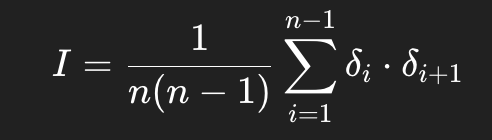

Where

𝛿_i = (𝑚_i − 𝑚bar)/𝜎

𝑚_i = observed magnitude at time i

𝑚bar = mean magnitude of the star

𝜎_𝑖 = uncertainty in m_i

Measurements are ordered by time

In [171]:
# Welch-Stetson I (I_WS) 
def compute_welch_stetson_iws(group):
    if len(group) < 2:
        return np.nan

    group = group.sort_values("mjd")
    m = group["mag"].values
    m_err = group["mag_err"].values
    mean_mag = np.average(m, weights=1/m_err**2)
    delta = (m - mean_mag) / m_err

    # the I index is the sum of products of adjacent residuals
    I = np.sum(delta[:-1] * delta[1:]) / (len(delta) - 1)
    return I

# test on ForcedSource g-band, clean and convert to mag
df = pd.read_csv("forcedsource.csv")
ZP = 25
df = df[(df["psfFlux"] > 0) & (~df["psfFlux_flag"]) & (~df["pixelFlags_edge"])]
df["mag"] = -2.5 * np.log10(df["psfFlux"]) + ZP
df["mag_err"] = 1.0857 * df["psfFluxErr"] / df["psfFlux"]

# test on each star
I_index = df.groupby("objectId").apply(compute_welch_stetson_iws, include_groups = False).reset_index()
I_index.columns = ["objectId", "I_WS"]

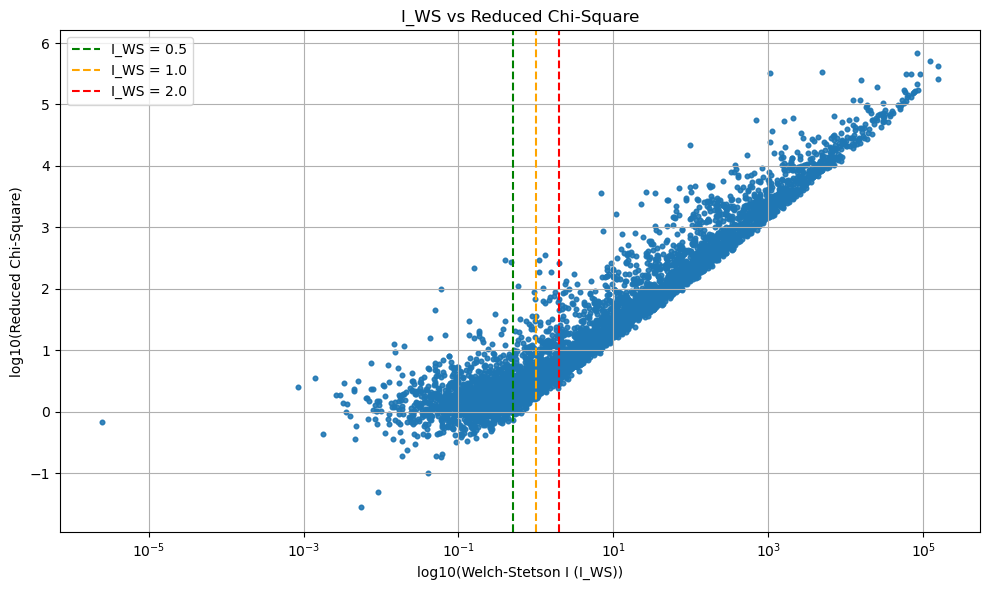

In [173]:
df_features = pd.read_csv("chi2_forcedsource_features.csv")
df_features["log_chi2"] = np.log10(df_features["chi2_reduced"])
df_merged = df_features.merge(I_index, on="objectId", how="left")
df_merged.to_csv("features_with_IWS.csv", index=False)


# I_WS vs log(chi^2)
plt.figure(figsize=(10, 6))
plt.scatter(df_merged["I_WS"], df_merged["log_chi2"], s=10, alpha=0.5)
plt.xscale("log")

# verical lines for I_WS
plt.axvline(0.5, color='green', linestyle='--', label= 'I_WS = 0.5')
plt.axvline(1.0, color='orange', linestyle='--', label= 'I_WS = 1.0')
plt.axvline(2.0, color='red', linestyle='--', label= 'I_WS = 2.0')

plt.xlabel("log10(Welch-Stetson I (I_WS))")
plt.ylabel("log10(Reduced Chi-Square)")
plt.title("I_WS vs Reduced Chi-Square")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [174]:
iws_df = df_raw.groupby("objectId").apply(compute_welch_stetson_iws, include_groups=False).reset_index(name="I_WS")

df_features = pd.read_csv("chi2_forcedsource_features.csv")
df_features["log_chi2"] = np.log10(df_features["chi2_reduced"])
df = df_features.merge(iws_df, on="objectId", how="left")
df.to_csv("features_with_IWS.csv", index=False)

In [175]:
### compute chi2 stats
chi2_clean = df["chi2_reduced"][df["chi2_reduced"] < 1e4]
mu = np.mean(chi2_clean)
sigma = np.std(chi2_clean)

In [148]:
print("Mean chi²:", np.mean(df["chi2_reduced"]))
print("Stddev chi²:", np.std(df["chi2_reduced"]))

print("Min chi²:", df["chi2_reduced"].min())
print("Max chi²:", df["chi2_reduced"].max())

Mean chi²: 2445.550516579161
Stddev chi²: 17857.377590426626
Min chi²: 0.0258101532332926
Max chi²: 683992.1090678576


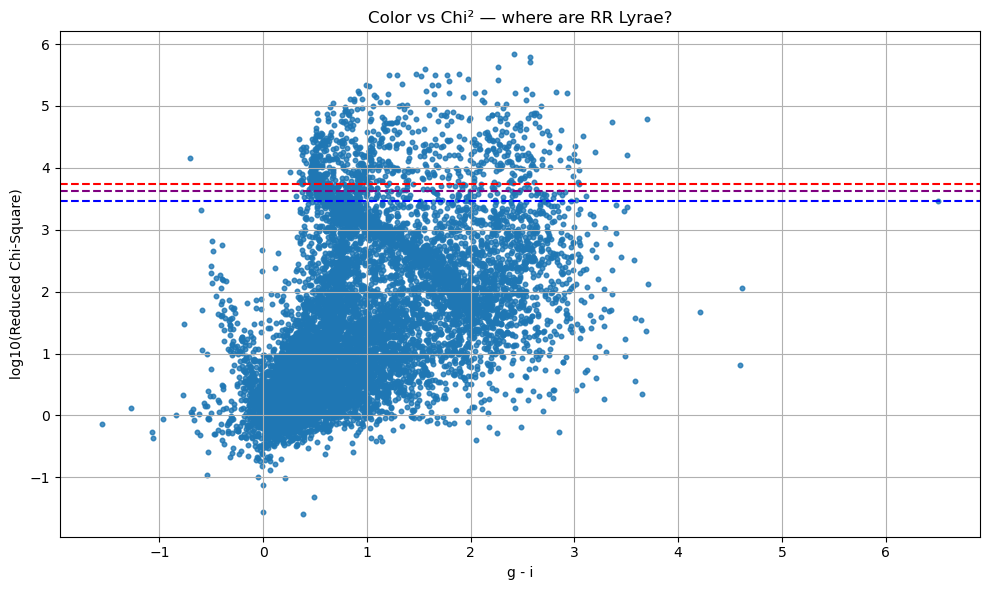

In [149]:
plt.figure(figsize=(10, 6))
plt.scatter(df["g_i"], np.log10(df["chi2_reduced"]), s=10, alpha=0.4)
plt.axhline(np.log10(thresh_rrlyrae), color='blue', linestyle='--')
plt.axhline(np.log10(thresh_cepheid), color='purple', linestyle='--')
plt.axhline(np.log10(thresh_mira), color='red', linestyle='--')
plt.xlabel("g - i")
plt.ylabel("log10(Reduced Chi-Square)")
plt.title("Color vs Chi² — where are RR Lyrae?")
plt.grid(True)
plt.tight_layout()
plt.show()


---

## Methods

### Reduced Chi-Square (χ²)

Quantifies deviation from a star's average brightness over time

- Fluxes converted to magnitudes (`m = -2.5 log₁₀(F) + ZP`, with ZP = 25)
- Used on both `DiaSource` and `ForcedSource` datasets
- Skewed distributions, used `log10(χ²)` in all plots

### Welch-Stetson I (I_WS)

Captures **correlated residuals** in sequential observations (sensitive to pulsation):

- Applied per object from `ForcedSource` data

---

## Key Findings

### Metric Behavior

- **I_WS and χ² are positively correlated** in log-log space.
- Most candidate variables fall in:
  - `log₁₀(I_WS)` ≈ 0 to 1.5
  - `log₁₀(χ²)` ≈ 1 to 5
- Combining both metrics provides **stronger detection power** than either alone.

### Source Comparison

#### DiaSource & DiaObject:
- Narrow χ² peak (~5–30)
- Indicates clean detection of clear variability

#### ForcedSource & Object:
- Same χ² peak (~10), but much broader
- Detects more subtle or noisy variability

---

### CMD & Color Relationships

- RR Lyrae: **bluer**, moderate χ², short period
- Cepheids: **intermediate color**, higher χ²
- Miras: **redder**, very high χ²
- **CMDs colored by log(χ²)** show clean clustering of star types

---

## Results

### Output Files

| File | Description |
|------|-------------|
| `chi2_diasource.csv` | Reduced χ² for each star (DiaSource) |
| `chi2_forcedsource.csv` | Reduced χ² (ForcedSource) |
| `features_with_IWS.csv` | Combined χ² + I_WS for each object |
| CMD plots | Color-magnitude diagrams colored by variability |
| Scatterplots | I_WS vs log(χ²), color vs log(χ²), etc. |
| Histograms | Show percentile thresholds in χ² distributions |

---

## Final Conclusions

- Reduced χ² and I_WS are effective and **complementary** for variability detection.
- CMD + variability thresholding can distinguish likely RR Lyrae, Cepheid, and Mira candidates.
- `DiaSource` is cleaner and narrower; `ForcedSource` is broader and more sensitive.
- RR Lyrae candidates likely exist in:
  - `g – i` ≈ 0.5–1.0
  - `log₁₀(χ²)` ≈ 3.5–4.0

This pipeline is now primed for:
- Star classification
- Outlier detection
- Machine learning-based variability searches